In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import folium
from folium.plugins import HeatMap
import glob
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

In [ ]:
Synthetic = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/synthetic.csv')
Advan = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/Advan.csv')

In [ ]:
synthetic_agg = (Synthetic.groupby(['lid', 'latitude', 'longitude', 'admin2'])
                 .size()
                 .reset_index(name='visit_count_synthetic'))

advan_agg = (Advan.groupby(['placekey', 'latitude', 'longitude', 'county'])
             .size()
             .reset_index(name='visit_count_advan'))
g_points = synthetic_agg[['latitude', 'longitude', 'visit_count_synthetic']].values.T
r_points = advan_agg[['latitude', 'longitude', 'visit_count_advan']].values.T

In [2]:
k_confirm = 2
g_manual = np.array([
    [37.5, -77.5, 10.0],
    [38.0, -78.0, 5.0],
    [37.8, -77.8, 8.0]
])
r_manual = np.array([
    [37.6, -77.6, 8.0],
    [38.1, -78.1, 6.0],
    [37.9, -77.9, 7.0]
])

ball_radius = 5

ball_r = NearestNeighbors(radius=ball_radius).fit(r_manual)
ball_g = NearestNeighbors(radius=ball_radius).fit(g_manual)

print(f"g_manual:\n{g_manual}")
print(f"\nr_manual:\n{r_manual}")

g_manual:
[[ 37.5 -77.5  10. ]
 [ 38.  -78.    5. ]
 [ 37.8 -77.8   8. ]]

r_manual:
[[ 37.6 -77.6   8. ]
 [ 38.1 -78.1   6. ]
 [ 37.9 -77.9   7. ]]


In [18]:
volume = (4/3) * np.pi * ball_radius**3
n_r = r_manual.shape[0]
n_g = g_manual.shape[0]

count_g_in_r = np.array([len(nbrs) for nbrs in ball_r.radius_neighbors(g_manual, return_distance=False)])
count_r_in_r = np.array([len(nbrs) - 1 for nbrs in ball_r.radius_neighbors(r_manual, return_distance=False)])

f_r_at_g = (count_g_in_r) / (n_r * volume)
f_r_at_r = (count_r_in_r) / (n_r * volume)

CE_GR = np.mean(np.log(1 / f_r_at_g))
H_R   = np.mean(np.log(1 / f_r_at_r))
PCE   = CE_GR - H_R

print(f"count_g_in_r: {count_g_in_r}")
print(f"count_r_in_r: {count_r_in_r}")
print(f"\nCE_GR = {CE_GR:.6f}")
print(f"H_R   = {H_R:.6f}")
print(f"PCE   = {PCE:.6f}")

count_g_in_r: [3 3 3]
count_r_in_r: [2 2 2]

CE_GR = 6.260726
H_R   = 6.666191
PCE   = -0.405465


In [16]:
count_r_in_g = np.array([len(nbrs) for nbrs in ball_g.radius_neighbors(r_manual, return_distance=False)])

f_g_at_r = (count_r_in_g / (n_g * volume))

CE_RG = np.mean(np.log(1 / f_g_at_r))
RCE   = CE_RG - H_R

print(f"count_r_in_g: {count_r_in_g}")
print(f"\nCE_RG = {CE_RG:.6f}")
print(f"H_R   = {H_R:.6f}")
print(f"RCE   = {RCE:.6f}")

count_r_in_g: [3 3 3]

CE_RG = 6.260726
H_R   = 6.666191
RCE   = -0.405465


In [19]:
count_g_in_g = np.array([len(nbrs) - 1 for nbrs in ball_g.radius_neighbors(g_manual, return_distance=False)])

f_g_at_g = (count_g_in_g) / (n_g * volume)

H_G = np.mean(np.log(1 / f_g_at_g))
RE  = H_G - H_R

print(f"count_g_in_g: {count_g_in_g}")
print(f"\nH_G = {H_G:.6f}")
print(f"H_R = {H_R:.6f}")
print(f"RE  = {RE:.6f}")

count_g_in_g: [1 1 2]

H_G = 7.128289
H_R = 6.666191
RE  = 0.462098


In [7]:
def draw_single_ball(ax, query_pt, ref_pts, ball_index, title, qcolor, rcolor,
                     qprefix, rprefix, q_label, exclude_self, all_ref_pts=None):
    t = np.linspace(0, 2 * np.pi, 100)
    u = np.linspace(0, 2 * np.pi, 24)
    v = np.linspace(0, np.pi, 14)
    su = np.outer(np.cos(u), np.sin(v))
    sv = np.outer(np.sin(u), np.sin(v))
    sw = np.outer(np.ones_like(u), np.cos(v))

    ax.set_facecolor('#0E1E2E')
    ax.view_init(elev=30, azim=55)

    plot_refs = all_ref_pts if all_ref_pts is not None else ref_pts
    ax.scatter(plot_refs[:, 0], plot_refs[:, 1], plot_refs[:, 2],
               color=rcolor, s=180, zorder=10, marker='o', alpha=1.0,
               label=f'Reference ({rprefix})', depthshade=False,
               edgecolors='#EDE8DF', linewidths=0.8)
    ax.scatter([query_pt[0]], [query_pt[1]], [query_pt[2]],
               color=qcolor, s=220, zorder=11, marker='x',
               linewidths=3.0, label=f'Query ({qprefix})', depthshade=False)

    ax.plot_surface(ball_radius * su + query_pt[0],
                    ball_radius * sv + query_pt[1],
                    ball_radius * sw + query_pt[2],
                    color=qcolor, alpha=0.06, linewidth=0, shade=False)
    ax.plot(query_pt[0] + ball_radius * np.cos(t), query_pt[1] + ball_radius * np.sin(t),
            np.full_like(t, query_pt[2]), color=qcolor, linewidth=2.2, alpha=0.9)

    idx_list = ball_index.radius_neighbors(query_pt.reshape(1, -1), return_distance=False)[0]
    count = 0
    label_offsets = np.linspace(-1.0, 1.0, max(len(plot_refs), 1))
    for k, p in enumerate(plot_refs):
        is_neighbor = any(np.allclose(p, ref_pts[j]) for j in idx_list) if len(idx_list) else False
        is_self = exclude_self and np.allclose(query_pt, p)
        if is_neighbor and not is_self:
            count += 1
            ax.plot([query_pt[0], p[0]], [query_pt[1], p[1]], [query_pt[2], p[2]],
                    color='#00CC88', linewidth=1.6, alpha=0.9, linestyle=':', zorder=3)
        ax.text(p[0], p[1], p[2] + label_offsets[k],
                f'{rprefix}{k+1}\nv={int(p[2])}',
                fontsize=7, color=rcolor, ha='center', zorder=15,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#1A3A5C',
                          edgecolor=rcolor, linewidth=0.7, alpha=0.95))

    ax.text(query_pt[0], query_pt[1], query_pt[2] + 1.4,
            f'{q_label}\ncount={count}',
            fontsize=9, color=qcolor, ha='center', zorder=16,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A3A5C',
                      edgecolor=qcolor, linewidth=1.2, alpha=0.98))

    all_pts = np.vstack([plot_refs, query_pt.reshape(1, -1)])
    center = (all_pts.max(axis=0) + all_pts.min(axis=0)) / 2
    half_span = (all_pts.max(axis=0) - all_pts.min(axis=0)) / 2 + ball_radius * 1.05
    ax.set_xlim(center[0] - half_span[0], center[0] + half_span[0])
    ax.set_ylim(center[1] - half_span[1], center[1] + half_span[1])
    ax.set_zlim(center[2] - half_span[2], center[2] + half_span[2])
    ax.set_box_aspect((half_span[0], half_span[1], half_span[2]))

    ax.set_xlabel('lat', fontsize=8, color='#EDE8DF', labelpad=6)
    ax.set_ylabel('lon', fontsize=8, color='#EDE8DF', labelpad=6)
    ax.set_zlabel('visits', fontsize=8, color='#EDE8DF', labelpad=6)
    ax.set_title(title, fontsize=10, color='#EDE8DF', pad=8)
    ax.tick_params(colors='#EDE8DF', labelsize=6)
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor('#1E2E42')
    ax.grid(True, color='#1E2E42', linewidth=0.3)
    ax.legend(fontsize=7, facecolor='#0E1E2E', edgecolor='#2A3F55',
              labelcolor='#EDE8DF', loc='upper left')

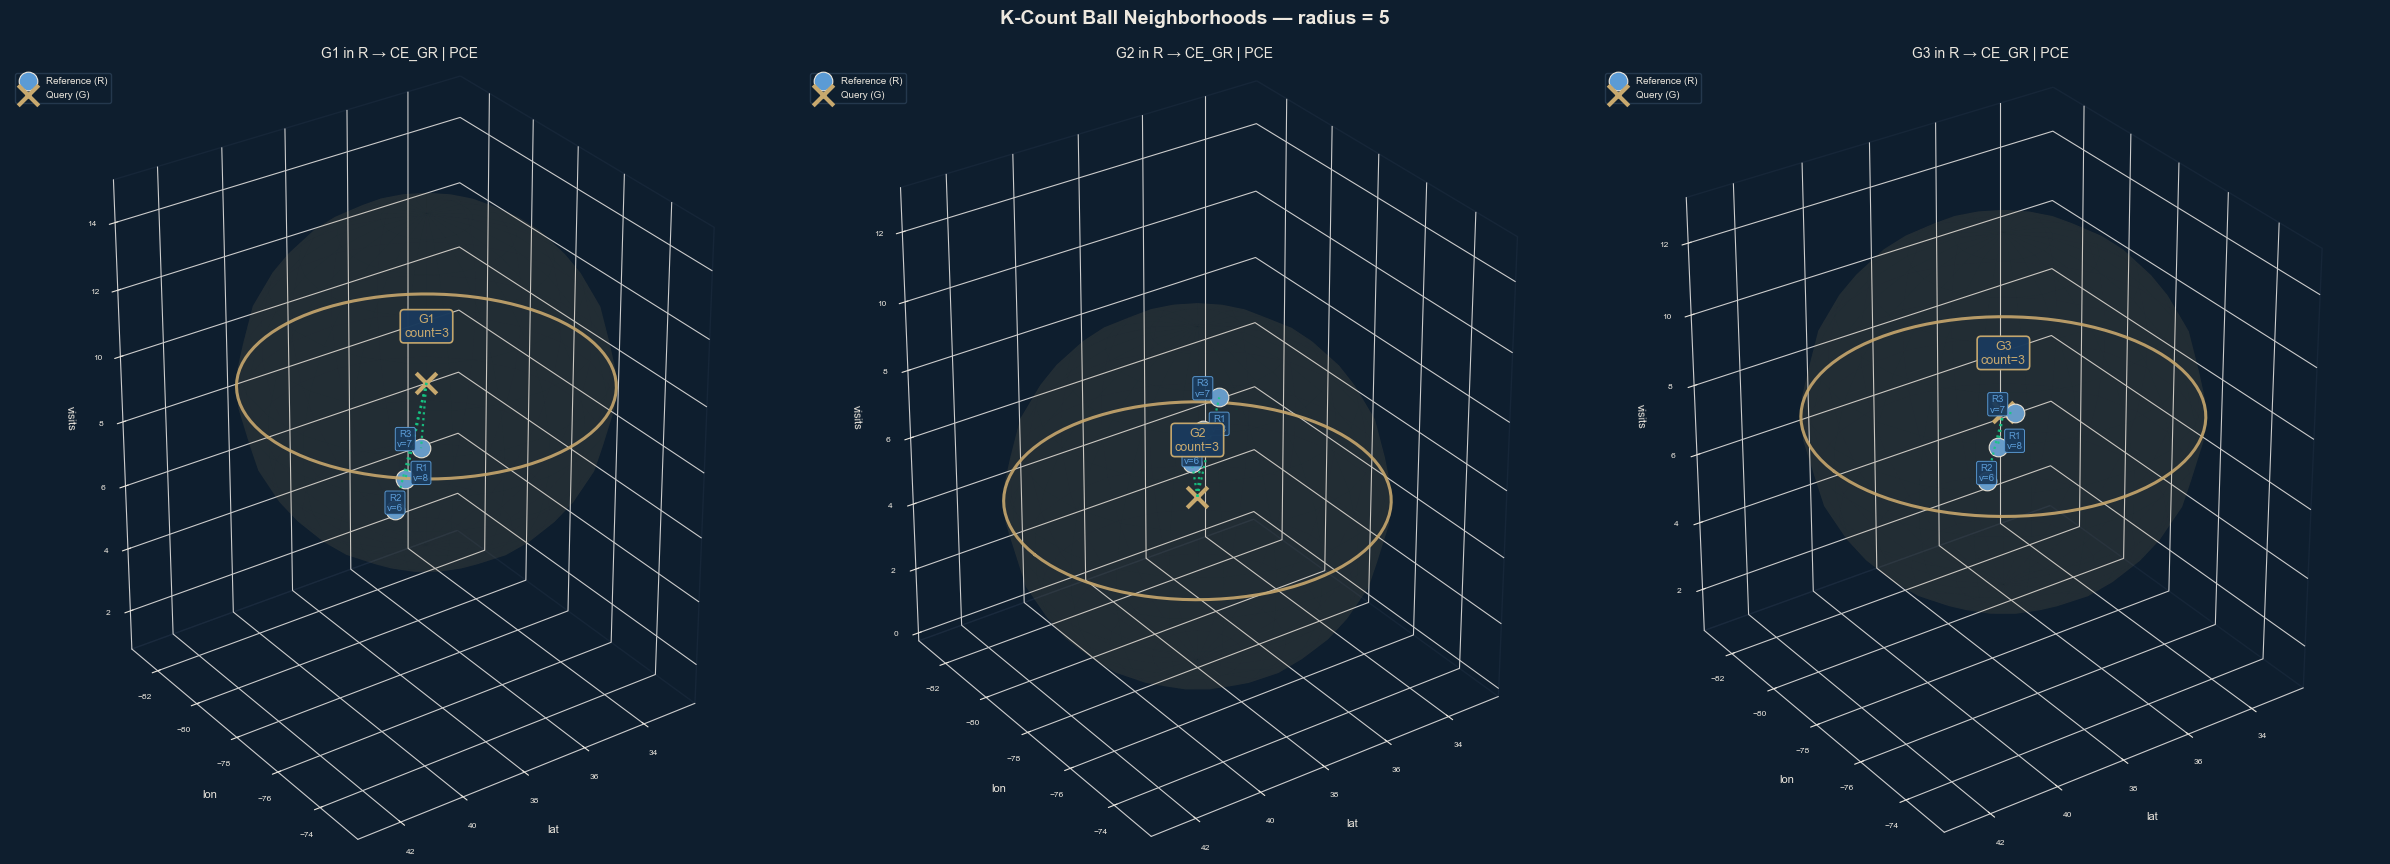

In [8]:
fig, axes = plt.subplots(1, len(g_manual), figsize=(24, 9),
                          subplot_kw={'projection': '3d'})
fig.patch.set_facecolor('#0E1E2E')

for i, ax in enumerate(axes):
    draw_single_ball(ax, g_manual[i], r_manual, ball_r,
                     f'G{i+1} in R → CE_GR | PCE', '#C8A96E', '#5B9BD5',
                     'G', 'R', f'G{i+1}', exclude_self=False)

plt.suptitle(f'K-Count Ball Neighborhoods — radius = {ball_radius}',
             fontsize=14, color='#EDE8DF', fontweight='bold')
plt.tight_layout()
plt.show()

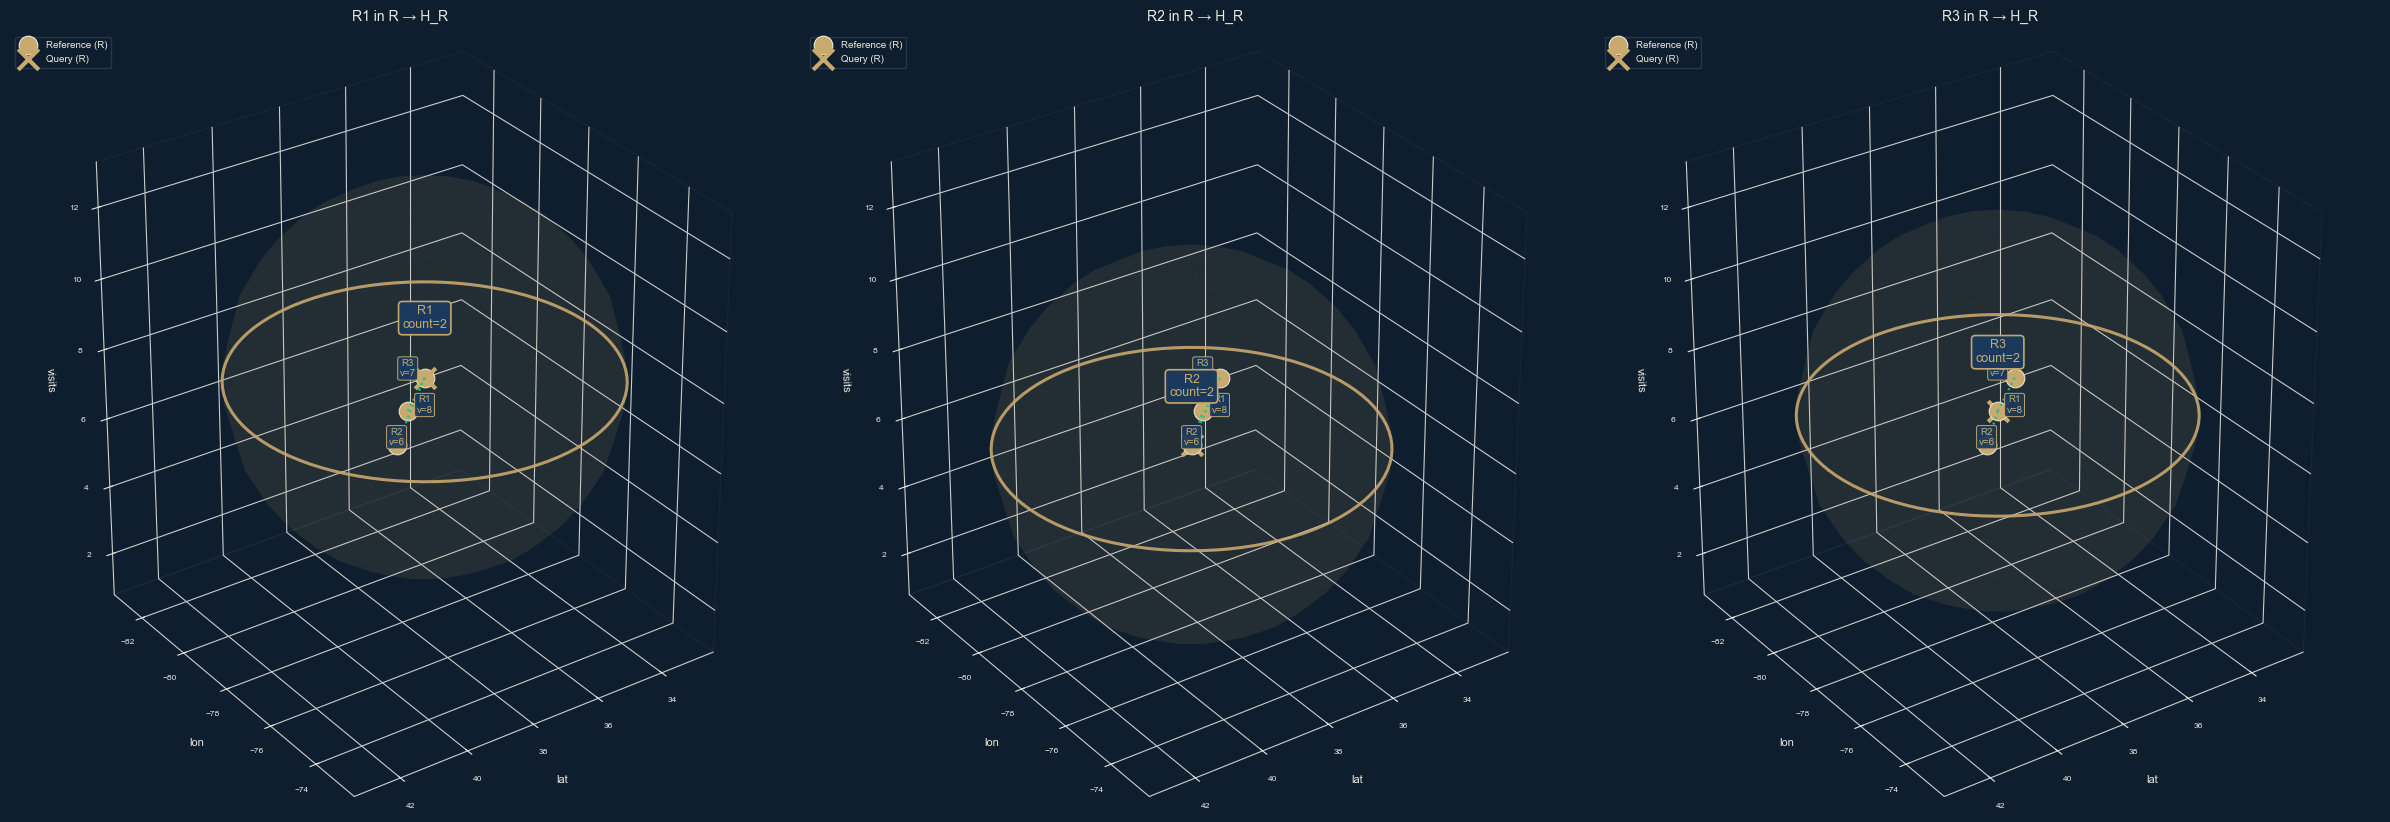

In [13]:
fig, axes = plt.subplots(1, len(r_manual), figsize=(24, 9),
                          subplot_kw={'projection': '3d'})
fig.patch.set_facecolor('#0E1E2E')

for i, ax in enumerate(axes):
    draw_single_ball(ax, r_manual[i], r_manual, ball_r,
                     f'R{i+1} in R → H_R', '#C8A96E', '#C8A96E',
                     'R', 'R', f'R{i+1}', exclude_self=True)

plt.tight_layout()
plt.show()

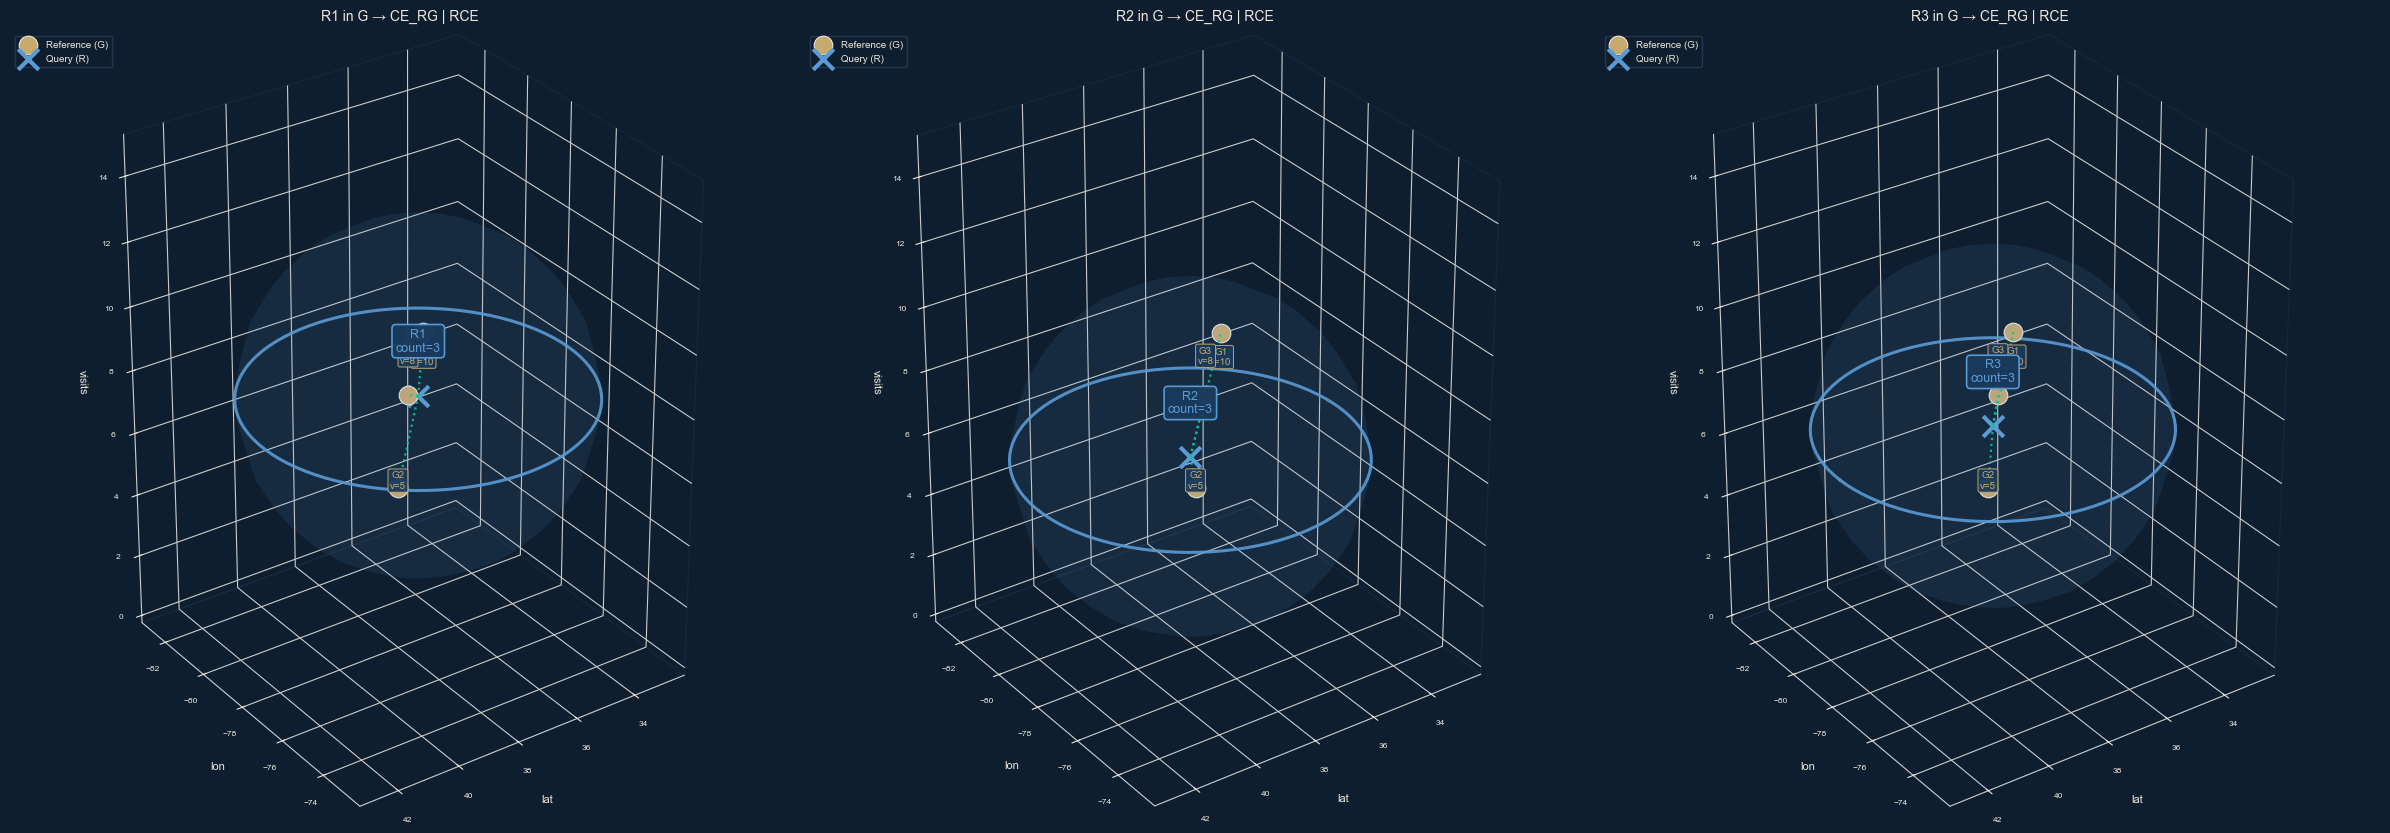

In [9]:
fig, axes = plt.subplots(1, len(r_manual), figsize=(24, 9),
                          subplot_kw={'projection': '3d'})
fig.patch.set_facecolor('#0E1E2E')

for i, ax in enumerate(axes):
    draw_single_ball(ax, r_manual[i], g_manual, ball_g,
                     f'R{i+1} in G → CE_RG | RCE', '#5B9BD5', '#C8A96E',
                     'R', 'G', f'R{i+1}', exclude_self=False)

plt.tight_layout()
plt.show()

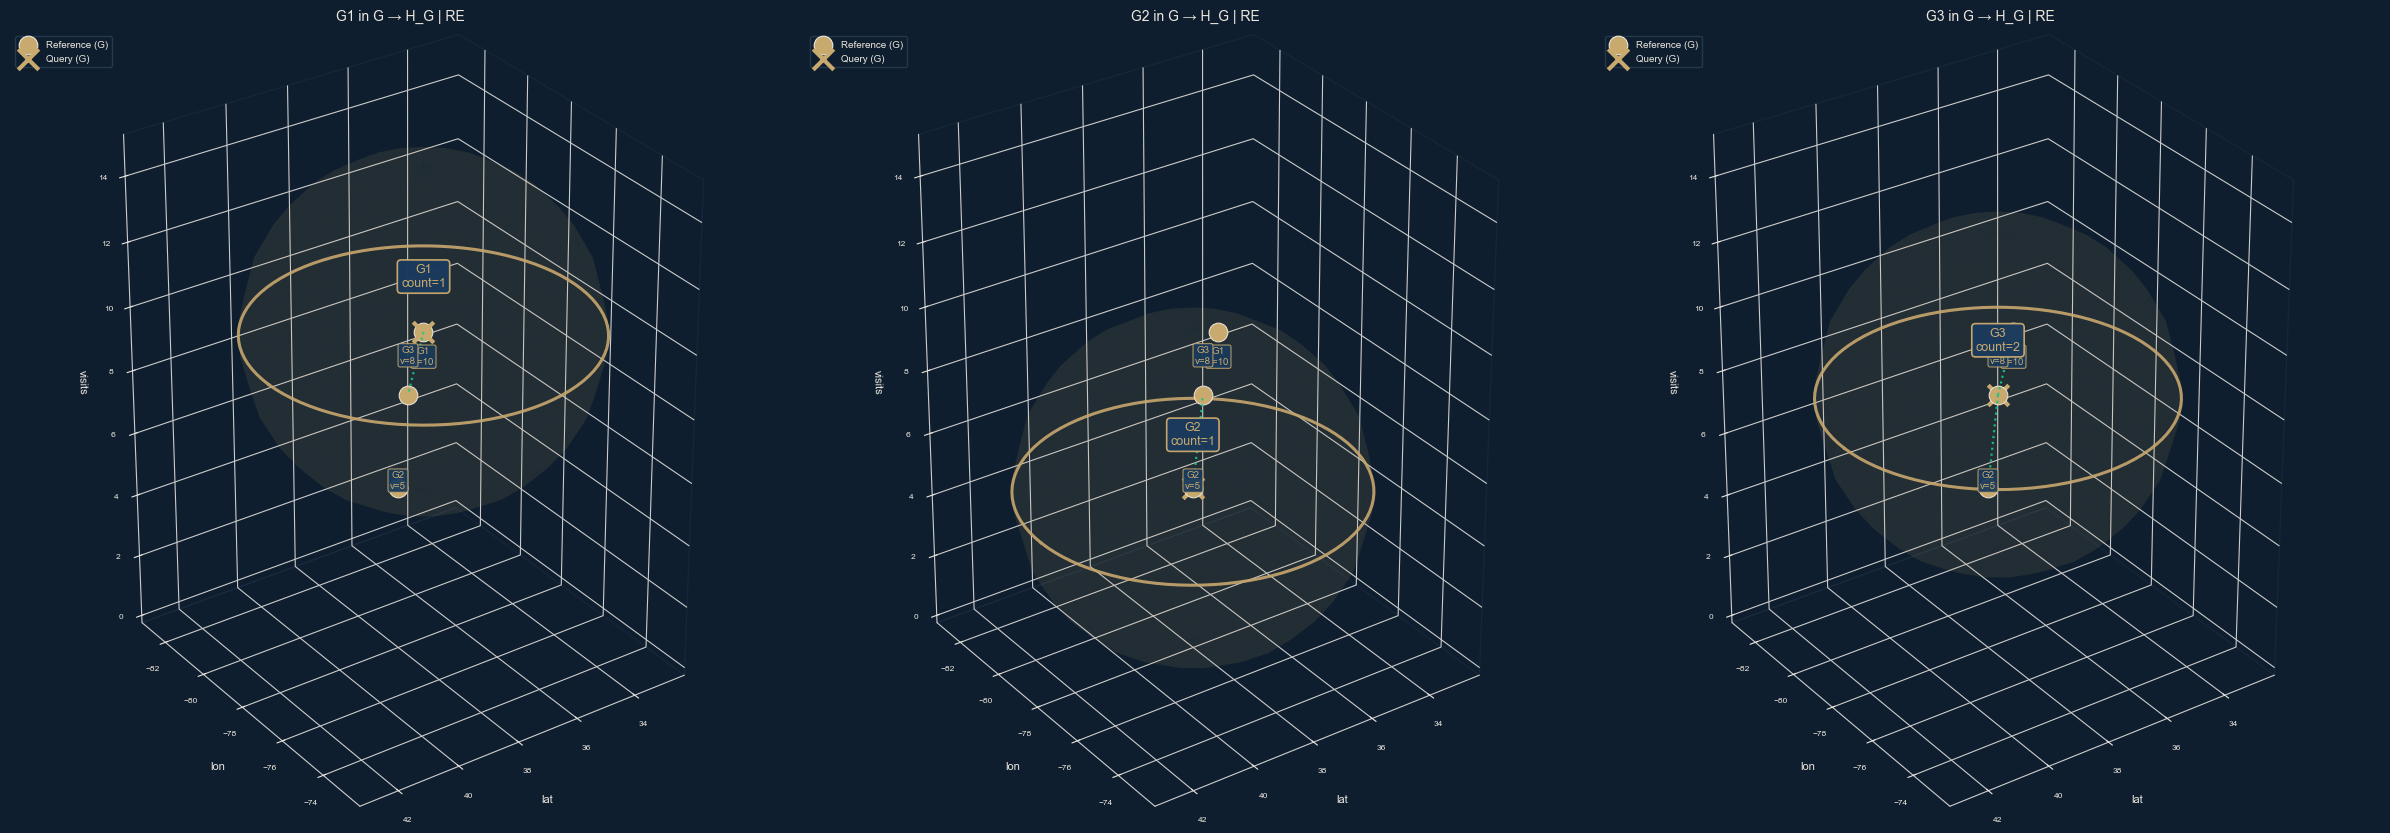

In [10]:
fig, axes = plt.subplots(1, len(g_manual), figsize=(24, 9),
                          subplot_kw={'projection': '3d'})
fig.patch.set_facecolor('#0E1E2E')

for i, ax in enumerate(axes):
    draw_single_ball(ax, g_manual[i], g_manual, ball_g,
                     f'G{i+1} in G → H_G | RE', '#C8A96E', '#C8A96E',
                     'G', 'G', f'G{i+1}', exclude_self=True)

plt.tight_layout()
plt.show()